In [1]:
import warnings
from pathlib import Path

import xarray as xr
import numpy as np

from imagematerials.buildings.preprocessing.floorspace import (
    compute_average_m2_capita,
    compute_housing_residential,
    compute_housing_type,
    extrapolate_floorspace,
    get_image_floorspace
)
from imagematerials.buildings.preprocessing.lifetimes import compute_lifetimes
from imagematerials.buildings.preprocessing.materials import (
    compute_mat_intensities_commercial,
    compute_mat_intensities_residential,
)
from imagematerials.buildings.preprocessing.population import compute_population_split
from imagematerials.concepts import create_building_graph



from matplotlib import pyplot as plt

from imagematerials.buildings.preprocessing.population import compute_population_split

from imagematerials.buildings.constants import quintiles_generic

In [2]:
base_directory = Path("..", "data", "raw")
scenario_sel = "SSP2_baseline"

database_directory = base_directory / "buildings" / "SSP2_CP"
image_directory = base_directory / "image" / scenario_sel

In [3]:
population = compute_population_split(image_directory)

c:\Users\Arp00003\AppData\Local\anaconda3\envs\materials_dev_new\Lib\site-packages\xarray\core\variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\Arp00003\AppData\Local\anaconda3\envs\materials_dev_new\Lib\site-packages\xarray\core\variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\Arp00003\AppData\Local\anaconda3\envs\materials_dev_new\Lib\site-packages\xarray\core\variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\Arp00003\AppData\Local\anaconda3\envs\materials_dev_new\Lib\site-packages\xarray\core\variable.py:336: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)
c:\Users\Arp00003\AppData\Local\anaconda3\envs\materials_dev_new\Lib\site-packages\xarray\core\index

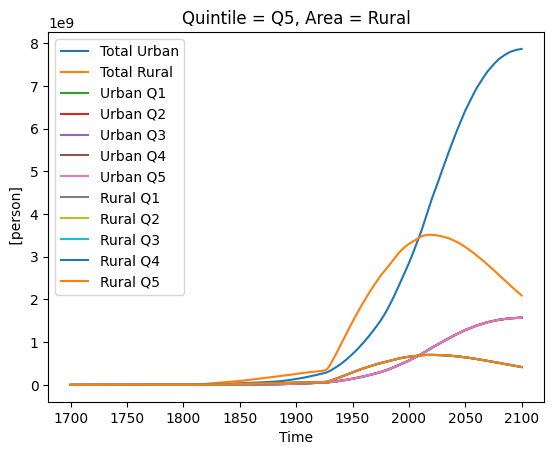

In [4]:
population.sum("Region").sel(Area='Urban').sum("Quintile").plot(label = "Total Urban")
population.sum("Region").sel(Area='Rural').sum("Quintile").plot(label="Total Rural")

for quintile in quintiles_generic:
    population.sum("Region").sel(Area='Urban').sel(Quintile = quintile).plot(label = f"Urban {quintile}")
for quintile in quintiles_generic:
    population.sum("Region").sel(Area='Rural').sel(Quintile = quintile).plot(label = f"Rural {quintile}")
plt.legend()

In [5]:
# Get floorspace for commercial + urban/rural
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    floorspace_residential_capita, floorspace_commercial_capita, minimum_comm = get_image_floorspace(image_directory, base_directory)
    
floorspace_residential_capita = extrapolate_floorspace(floorspace_residential_capita)
floorspace_commercial_capita = extrapolate_floorspace(floorspace_commercial_capita, minimum_comm)

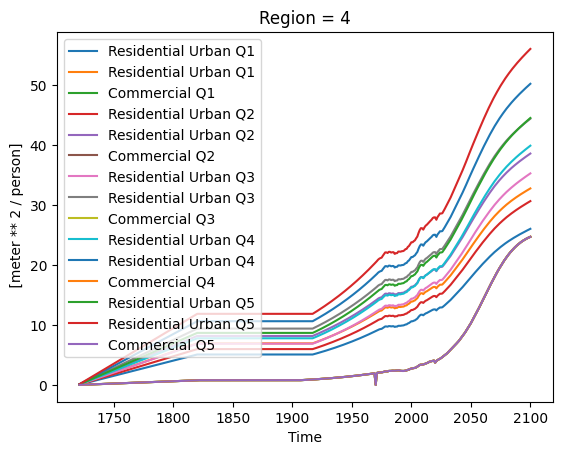

In [6]:
for quintile in quintiles_generic:
    floorspace_residential_capita.sel(Region = "4", Area = "Urban").sel(Quintile = quintile).plot(label = f"Residential Urban {quintile}")
    floorspace_residential_capita.sel(Region = "4", Area = "Rural").sel(Quintile = quintile).plot(label = f"Residential Urban {quintile}")
    floorspace_commercial_capita.sel(Region = "4").sum("Type").plot(label = f"Commercial {quintile}")

plt.legend()

In [7]:
# Average square meter per capita split by residential type [Region, Area, Type]
from imagematerials.buildings.constants import area_graph
average_m2_capita = compute_average_m2_capita(base_directory)

housing_type = compute_housing_type(database_directory)

In [8]:
# Floorspace m2 for residential buildings [Year, Region, Area, Type]
floorspace_residential = compute_housing_residential(population, 
                                                     average_m2_capita, 
                                                     housing_type, 
                                                     floorspace_residential_capita, {"CE":None})



In [9]:
# Commercial floorspace also needs to be multiplied by population & drop Area dimension
floorspace_commercial_capita * population.sel(Area=['Urban', 'Rural']).sum(["Quintile", "Area"]).loc[1721:]

Magnitude,[[[0.0 0.0 0.0 0.0] [0.0 0.0 0.0 0.0] [0.0 0.0 0.0 0.0] ... [0.0 0.0 0.0 0.0] [0.0 0.0 0.0 0.0] [0.0 0.0 0.0 0.0]] [[0.0 0.0 0.0 0.0] [0.0 0.0 0.0 0.0] [0.0 0.0 0.0 0.0] ... [0.0 0.0 0.0 0.0] [0.0 0.0 0.0 0.0] [0.0 0.0 0.0 0.0]] [[0.0 0.0 0.0 0.0] [0.0 0.0 0.0 0.0] [0.0 0.0 0.0 0.0] ... [0.0 0.0 0.0 0.0] [0.0 0.0 0.0 0.0] [0.0 0.0 0.0 0.0]] ... [[449437189.8804848 137055131.46994618 192631083.44461322 361677670.7678362] [4092366099.1499615 1237987165.421353 1759947143.232016 3295646564.2192793] [1391221186.1920128 330624773.3753803 603083236.4684924 994179437.9152727] ... [460746222.56337726 138391602.146462 198703445.28050572 371119090.64020145] [7718413946.418451 1736599423.4227653 3281674397.270491 5233342517.039263] [3735887831.400181 558061468.6511621 1123090447.8863466 1390879649.921485]] [[448844028.9203258 136945876.87566575 192332972.4937686 361175835.6640882] [4090967573.4887915 1238455340.8609533 1758828801.2464974 3294382216.175172] [1391167192.8379622 332698066.17241895 604130501.787396 999665999.8685822] ... [460542992.23530906 138490620.29966125 198527863.2845525 370953160.95394963] [7758146406.532963 1769502645.9304929 3316688228.4868207 5333362483.525534] [3810500737.9835677 581684531.6839027 1176390428.03435 1476174115.537554]] [[448249597.91257 136833457.6974288 192035887.76074874 360672998.0838772] [4089552578.472977 1238889403.7793539 1757717624.1709132 3293095820.702391] [1391005711.7293055 334722521.3335831 605058253.6525145 1004906132.1791626] ... [460335919.0976734 138582129.7541229 198353334.67643985 370780822.7885987] [7795137324.227219 1801356504.2291613 3348717642.0277505 5427853605.163758] [3882234381.040167 605258221.2258598 1228888858.9556062 1561968676.3595638]]]
Units,meter2


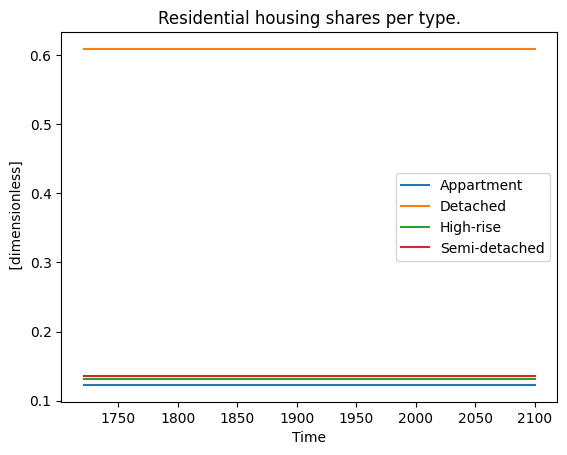

In [20]:
# Residential housing type shares [Year, Region, Area, Type]
housing_type = compute_housing_type(database_directory)
for res_type in housing_type.coords["Type"].values:
    housing_type.mean(["Region", "Area", "Quintile"]).sel(Type=res_type).plot(label=res_type)
plt.title("Residential housing shares per type.")
plt.legend()
plt.show()

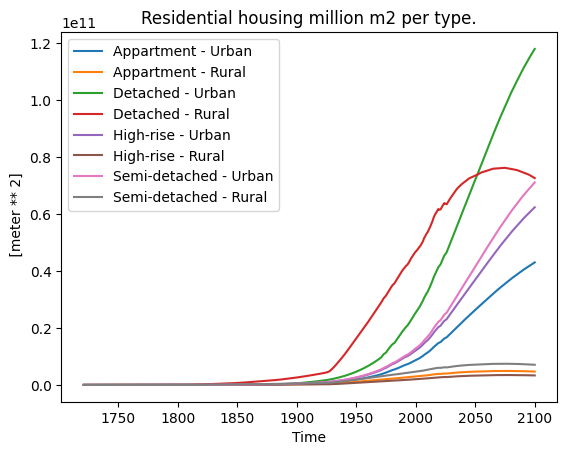

In [23]:
for res_type in floorspace_residential.coords["Type"].values:
    floorspace_residential.sum(["Region", "Quintile"]).sel(Type=res_type).plot(label=res_type)
plt.title("Residential housing million m2 per type.")
plt.legend()
plt.show()

In [18]:
floorspace_commercial_total = floorspace_commercial_capita * population.sel({"Area": "Total"})

In [ ]:
circular_economy_config = {"test": None}

floorspace_commercial_total = floorspace_commercial_total.drop_vars("Area")
floorspace = xr.concat((floorspace_residential, floorspace_commercial_total), dim="Type")

# Lifetime computations, see lifetimes.py

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    lifetimes = compute_lifetimes(base_directory, floorspace_commercial.coords["Type"].values, circular_economy_config)

mat_intensities_comm = compute_mat_intensities_commercial(database_directory, circular_economy_config)
mat_intensities_res = compute_mat_intensities_residential(database_directory, circular_economy_config)
mat_intensities = xr.concat((mat_intensities_res, mat_intensities_comm), dim="Type")
knowledge_graph = create_building_graph()
mat_intensities = knowledge_graph.rebroadcast_xarray(
                        mat_intensities, floorspace.coords["Type"].values)

#TODO remove this quick fix
region_coords = np.sort(floorspace.coords["Region"].values.astype(int)).astype(str)